# CS6140 — User Simulator: XGBoost vs GRU4Rec
**Dataset**: MovieLens 1M | **Label**: rating ≥ 4 → like

| Phase | Content |
|---|---|
| 1 | EDA: basic stats, fatigue signal, user activity |
| 2 | XGBoost: baseline → feature ablation → param ablation → diagnostics |
| 3 | GRU4Rec (next notebook) |

## 0. Setup

In [2]:
!wget -q --show-progress https://files.grouplens.org/datasets/movielens/ml-1m.zip
!unzip -q ml-1m.zip
!pip install -q xgboost shap scikit-learn scipy
print('✓ ready')

ml-1m.zip           100%[===================>]   5.64M  3.43MB/s    in 1.6s    
✓ ready


## 1. Data Loader

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from scipy import stats as sp
warnings.filterwarnings('ignore')

LIKE_THRESHOLD = 4
RANDOM_SEED    = 42

ALL_GENRES = [
    'Action','Adventure','Animation','Childrens','Comedy','Crime',
    'Documentary','Drama','Fantasy','FilmNoir','Horror','Musical',
    'Mystery','Romance','SciFi','Thriller','War','Western',
]

def load_ratings(path='ml-1m/ratings.dat'):
    df = pd.read_csv(path, sep='::', engine='python', header=None,
                     names=['user_id','movie_id','rating','timestamp'])
    df['like']      = (df['rating'] >= LIKE_THRESHOLD).astype(int)
    df['timestamp'] = df['timestamp'].astype(int)
    df = df.sort_values(['user_id','timestamp']).reset_index(drop=True)
    n_u, n_m = df['user_id'].nunique(), df['movie_id'].nunique()
    print(f'[ratings] {len(df):,} | {n_u:,} users | {n_m:,} movies | '
          f'like={df["like"].mean():.1%} | density={len(df)/(n_u*n_m):.2%}')
    return df

def load_movies(path='ml-1m/movies.dat'):
    df = pd.read_csv(path, sep='::', engine='python', header=None,
                     names=['movie_id','title','genres'], encoding='latin-1')
    df['year'] = df['title'].str.extract(r'\((\d{4})\)$').astype(float)
    raw = df['genres'].str.replace("Children's",'Childrens',regex=False)\
                      .str.replace('Film-Noir','FilmNoir',regex=False)
    for g in ALL_GENRES:
        df[f'genre_{g}'] = raw.str.contains(g, regex=False).astype(int)
    genre_cols = [c for c in df.columns if c.startswith('genre_')]
    df['n_genres'] = df[genre_cols].sum(axis=1)
    print(f'[movies]  {len(df):,} movies | {len(genre_cols)} genres | '
          f'year {int(df["year"].min())}–{int(df["year"].max())}')
    return df

def load_users(path='ml-1m/users.dat'):
    df = pd.read_csv(path, sep='::', engine='python', header=None,
                     names=['user_id','gender','age','occupation','zip'])
    df['gender_enc'] = (df['gender'] == 'M').astype(int)
    df['age_enc']    = df['age'].map({1:0,18:1,25:2,35:3,45:4,50:5,56:6}).fillna(0).astype(int)
    print(f'[users]   {len(df):,} users | M={df["gender_enc"].mean():.1%} | '
          f'occupations={df["occupation"].nunique()}')
    return df

def temporal_split_global(df, val_ratio=0.10, test_ratio=0.10):
    """
    Segmented by global timestamp, strictly ensuring that
    all events in train < all events in val < all events in test.
    """
    df_sorted = df.sort_values('timestamp').reset_index(drop=True)
    n         = len(df_sorted)
    train_end = int(n * (1 - val_ratio - test_ratio))
    val_end   = int(n * (1 - test_ratio))

    train = df_sorted.iloc[:train_end].copy()
    val   = df_sorted.iloc[train_end:val_end].copy()
    test  = df_sorted.iloc[val_end:].copy()

    print(f'[split] train {len(train):,} | val {len(val):,} | test {len(test):,}')

    # Leagage verification
    assert train['timestamp'].max() <= val['timestamp'].min(), 'Data Leaked！'
    assert val['timestamp'].max()   <= test['timestamp'].min(), 'Data Leaked！'
    print(f'  train: → {pd.to_datetime(train["timestamp"].max(), unit="s").date()}')
    print(f'  val  : {pd.to_datetime(val["timestamp"].min(), unit="s").date()} → '
          f'{pd.to_datetime(val["timestamp"].max(), unit="s").date()}')
    print(f'  test : {pd.to_datetime(test["timestamp"].min(), unit="s").date()} →')
    print('  ✓ No Leakage')
    return train, val, test

# ── Cell: Per-user Temporal Split ──

def temporal_split_per_user(df, val_ratio=0.10, test_ratio=0.10):
    train_list, val_list, test_list = [], [], []

    for uid, grp in df.groupby('user_id'):
        grp = grp.sort_values('timestamp')
        n   = len(grp)

        train_end = int(n * (1 - val_ratio - test_ratio))
        val_end   = int(n * (1 - test_ratio))

        if train_end == 0:          train_end = 1
        if val_end <= train_end:    val_end   = train_end + 1
        if val_end >= n:            val_end   = n - 1

        train_list.append(grp.iloc[:train_end])
        val_list.append(grp.iloc[train_end:val_end])
        test_list.append(grp.iloc[val_end:])

    train = pd.concat(train_list).reset_index(drop=True)
    val   = pd.concat(val_list).reset_index(drop=True)
    test  = pd.concat(test_list).reset_index(drop=True)

    print(f'[per-user split] train {len(train):,} | '
          f'val {len(val):,} | test {len(test):,}')

    # Leagage Verification
    leakage = 0
    for uid in df['user_id'].unique():
        tr = train[train['user_id']==uid]['timestamp']
        te = test[test['user_id']==uid]['timestamp']
        if len(tr) > 0 and len(te) > 0:
            if tr.max() > te.min():
                leakage += 1
    print(f'✓ Number of leakage using per-user : {leakage}')

    for name, d in [('train',train),('val',val),('test',test)]:
        ts_min = pd.to_datetime(d['timestamp'].min(), unit='s').date()
        ts_max = pd.to_datetime(d['timestamp'].max(), unit='s').date()
        print(f'  {name:<6}: {ts_min} → {ts_max} | n={len(d):,}')

    return train, val, test

# ── Load ──────────────────────────────────────────────────────────
ratings = load_ratings()
movies  = load_movies()
users   = load_users()

[ratings] 1,000,209 | 6,040 users | 3,706 movies | like=57.5% | density=4.47%
[movies]  3,883 movies | 18 genres | year 1919–2000
[users]   6,040 users | M=71.7% | occupations=21


## Phase 1 — EDA
### 1.1 Basic Statistics

Matrix density : 4.47%
Like rate      : 57.5%
Ratings/user   : mean=166 min=20 max=2314


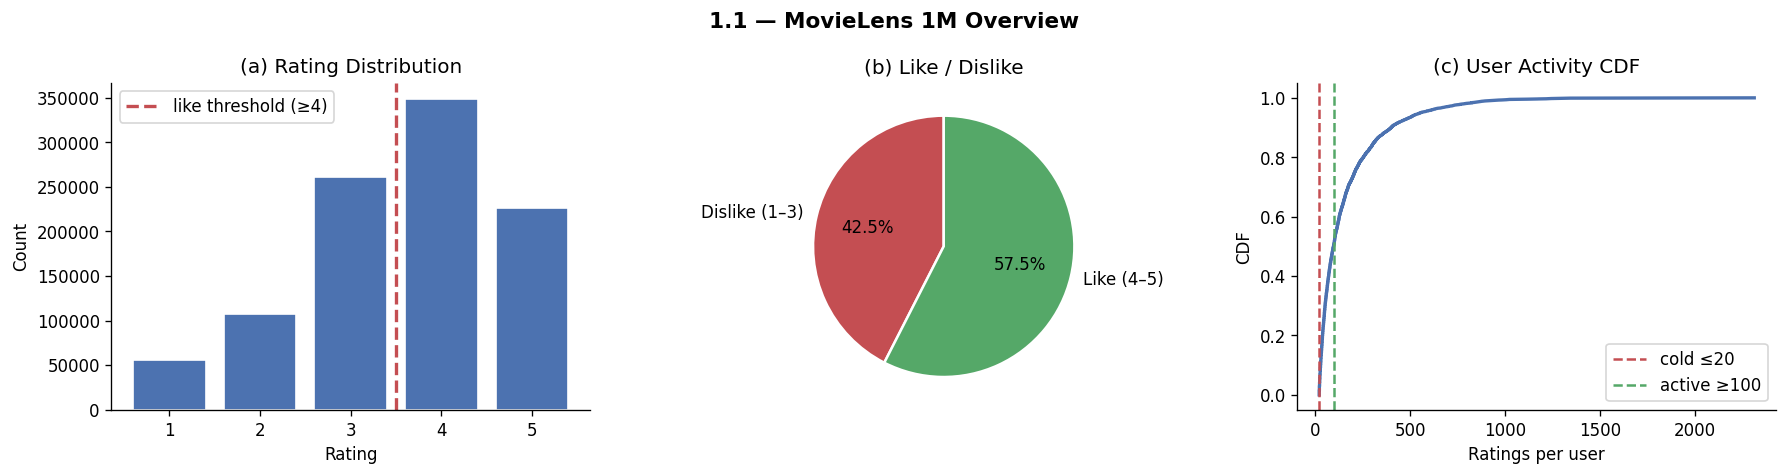

In [4]:
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3']
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False})

n_u = ratings['user_id'].nunique()
n_m = ratings['movie_id'].nunique()
print(f'Matrix density : {len(ratings)/(n_u*n_m):.2%}')
print(f'Like rate      : {ratings["like"].mean():.1%}')
print(f'Ratings/user   : mean={ratings.groupby("user_id").size().mean():.0f} '
      f'min={ratings.groupby("user_id").size().min()} '
      f'max={ratings.groupby("user_id").size().max()}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('1.1 — MovieLens 1M Overview', fontsize=13, fontweight='bold')

# (a) rating bar chart
ax = axes[0]
cnt = ratings['rating'].value_counts().sort_index()
ax.bar(cnt.index, cnt.values, color=PALETTE[0], edgecolor='white')
ax.axvline(3.5, color=PALETTE[3], ls='--', lw=2, label='like threshold (≥4)')
ax.set_xlabel('Rating'); ax.set_ylabel('Count')
ax.set_title('(a) Rating Distribution'); ax.legend()

# (b) like/dislike pie
ax = axes[1]
lc = ratings['like'].value_counts().sort_index()
ax.pie(lc, labels=['Dislike (1–3)','Like (4–5)'],
       colors=[PALETTE[3], PALETTE[2]], autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('(b) Like / Dislike')

# (c) ratings per user CDF
ax = axes[2]
rpu = ratings.groupby('user_id').size().sort_values()
ax.plot(rpu.values, np.arange(1,len(rpu)+1)/len(rpu), color=PALETTE[0], lw=2)
ax.axvline(20,  color=PALETTE[3], ls='--', lw=1.5, label='cold ≤20')
ax.axvline(100, color=PALETTE[2], ls='--', lw=1.5, label='active ≥100')
ax.set_xlabel('Ratings per user'); ax.set_ylabel('CDF')
ax.set_title('(c) User Activity CDF'); ax.legend()

plt.tight_layout(); plt.show()

### 1.2 Fatigue Signal

 run_position  mean_rating      sem  like_rate      n
            1     3.604527 0.001475   0.583964 570259
            2     3.606248 0.002898   0.584560 148238
            3     3.608047 0.004382   0.586586  64768
            4     3.606040 0.005885   0.586907  36326
            5     3.582251 0.007281   0.576495  23799
            6     3.587556 0.008540   0.576882  17052
            7     3.580359 0.009695   0.574537  13054
            8     3.594584 0.010835   0.577744  10451
            9     3.595110 0.011947   0.584230   8548
           10     3.594716 0.012990   0.579897   7153

Δ rating pos1→pos5 = -0.022 | t=2.998 | p=0.0027


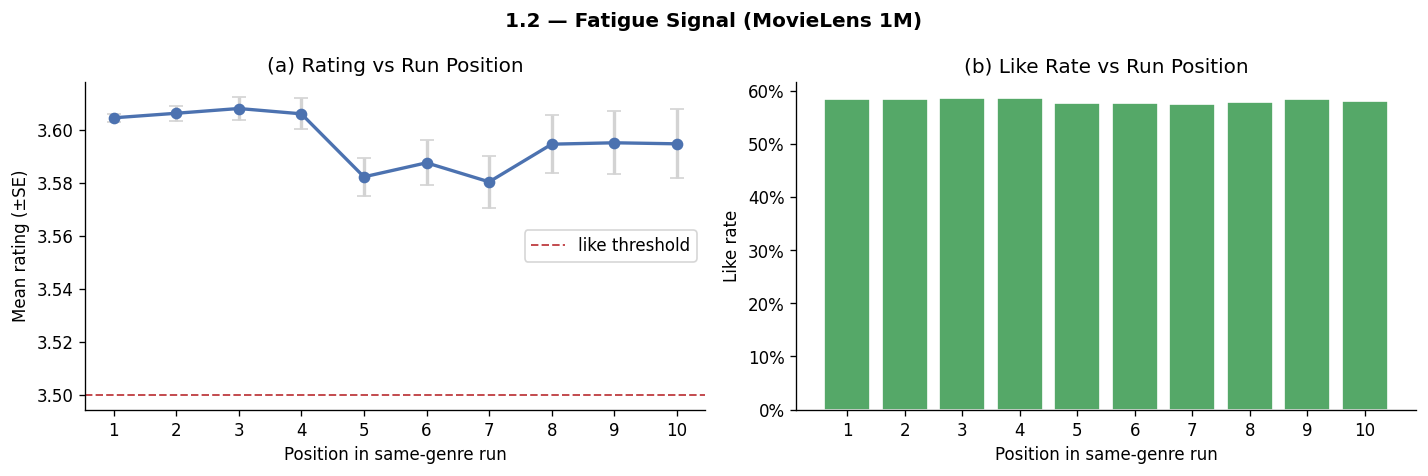

In [ ]:
genre_cols = [c for c in movies.columns if c.startswith('genre_')]

# Primary genre = first flagged genre column
def get_primary(row):
    for g in genre_cols:
        if row[g] == 1: return g.replace('genre_','')
    return 'Unknown'
movies['primary_genre'] = movies[genre_cols].apply(get_primary, axis=1)

merged = ratings.merge(movies[['movie_id','primary_genre']], on='movie_id', how='left')
merged['primary_genre'] = merged['primary_genre'].fillna('Unknown')

# Vectorised run-position detection
merged['prev_genre']   = merged.groupby('user_id')['primary_genre'].shift(1)
merged['run_start']    = (merged['primary_genre'] != merged['prev_genre']) | merged['prev_genre'].isna()
merged['run_id']       = merged.groupby('user_id')['run_start'].cumsum()
merged['run_position'] = merged.groupby(['user_id','run_id']).cumcount() + 1

MAX_POS = 10
sub = merged[merged['run_position'] <= MAX_POS]
agg = (sub.groupby('run_position')
       .agg(mean_rating=('rating','mean'),
            sem=('rating', lambda x: x.std()/np.sqrt(len(x))),
            like_rate=('like','mean'),
            n=('rating','count'))
       .reset_index())
print(agg.to_string(index=False))

p1 = sub[sub['run_position']==1]['rating']
p5 = sub[sub['run_position']==5]['rating']
t, p = sp.ttest_ind(p1, p5, equal_var=False)
delta = agg.iloc[4]['mean_rating'] - agg.iloc[0]['mean_rating']
print(f'\nΔ rating pos1→pos5 = {delta:+.3f} | t={t:.3f} | p={p:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('1.2 — Fatigue Signal (MovieLens 1M)', fontsize=12, fontweight='bold')

ax = axes[0]
ax.errorbar(agg['run_position'], agg['mean_rating'], yerr=agg['sem'],
            fmt='-o', color=PALETTE[0], ecolor='lightgray', capsize=4, lw=2)
ax.axhline(3.5, color=PALETTE[3], ls='--', lw=1.2, label='like threshold')
ax.set_xlabel('Position in same-genre run'); ax.set_ylabel('Mean rating (±SE)')
ax.set_title('(a) Rating vs Run Position'); ax.set_xticks(range(1,MAX_POS+1)); ax.legend()

ax = axes[1]
ax.bar(agg['run_position'], agg['like_rate'], color=PALETTE[2], edgecolor='white')
ax.set_xlabel('Position in same-genre run'); ax.set_ylabel('Like rate')
ax.set_title('(b) Like Rate vs Run Position'); ax.set_xticks(range(1,MAX_POS+1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout(); plt.show()

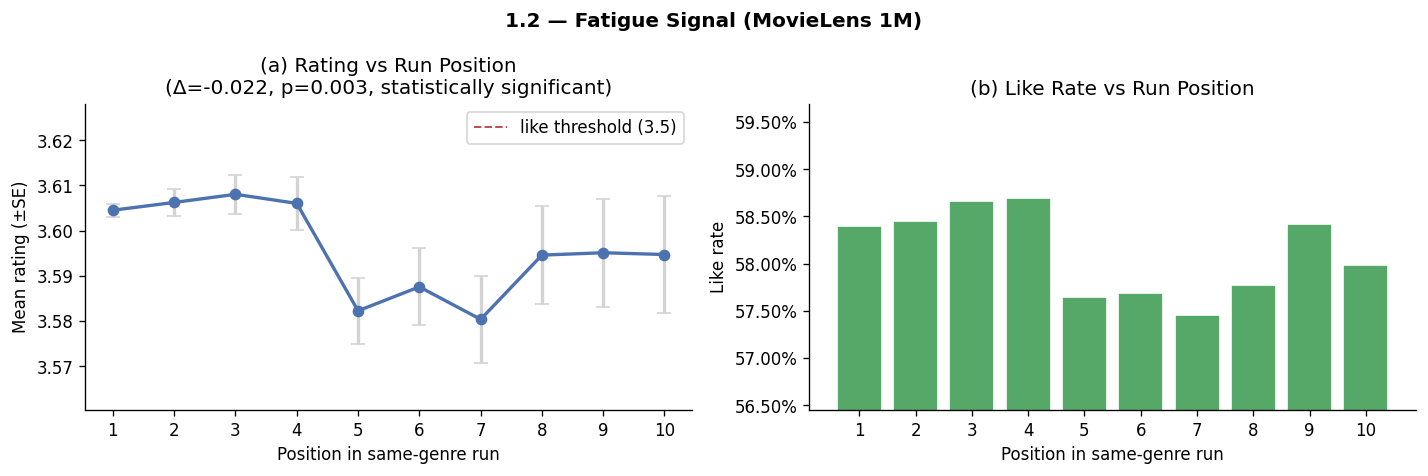

In [ ]:
# ── 1.2 Adjusted Plot to see the Fatigue Signal ──

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('1.2 — Fatigue Signal (MovieLens 1M)',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.errorbar(agg['run_position'], agg['mean_rating'],
            yerr=agg['sem'], fmt='-o', color='#4C72B0',
            ecolor='lightgray', capsize=4, lw=2)
ax.axhline(3.5, color='#C44E52', ls='--', lw=1.2,
           label='like threshold (3.5)')

# ★ Key: Shrink the Y-axis to make minute changes visible.
y_min = agg['mean_rating'].min() - 0.02
y_max = agg['mean_rating'].max() + 0.02
ax.set_ylim(y_min, y_max)

ax.set_xlabel('Position in same-genre run')
ax.set_ylabel('Mean rating (±SE)')
ax.set_title(f'(a) Rating vs Run Position\n'
             f'(Δ={agg.iloc[4]["mean_rating"]-agg.iloc[0]["mean_rating"]:+.3f}'
             f', p=0.003, statistically significant)')
ax.set_xticks(range(1, 11))
ax.legend()

ax = axes[1]
# ★ The like_rate Y-axis is also reduced.
bars = ax.bar(agg['run_position'], agg['like_rate'],
              color='#55A868', edgecolor='white')
y_min2 = agg['like_rate'].min() - 0.01
y_max2 = agg['like_rate'].max() + 0.01
ax.set_ylim(y_min2, y_max2)
ax.set_xlabel('Position in same-genre run')
ax.set_ylabel('Like rate')
ax.set_title('(b) Like Rate vs Run Position')
ax.set_xticks(range(1, 11))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

### 1.3 User Activity Distribution

               n_users  median_ratings  mean_like_rate
segment                                               
Active (≥100)     2945           212.0        0.594393
Cold (≤20)          86            20.0        0.606395
Regular           3009            46.0        0.651165


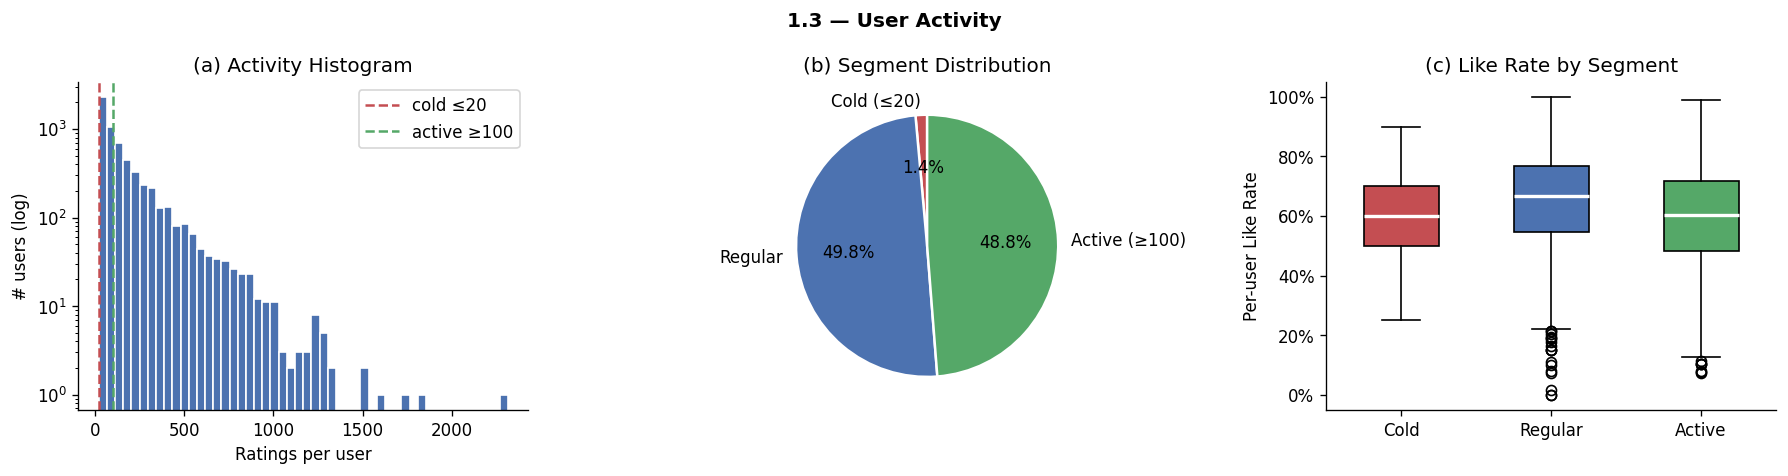

In [ ]:
COLD_THR   = 20
ACTIVE_THR = 100

user_stats = (ratings.groupby('user_id')
              .agg(n_ratings=('movie_id','count'),
                   like_rate=('like','mean'),
                   mean_rating=('rating','mean'))
              .reset_index())

def seg(n):
    if n <= COLD_THR:   return f'Cold (≤{COLD_THR})'
    if n >= ACTIVE_THR: return f'Active (≥{ACTIVE_THR})'
    return f'Regular'
user_stats['segment'] = user_stats['n_ratings'].apply(seg)

print(user_stats.groupby('segment').agg(
    n_users=('user_id','count'),
    median_ratings=('n_ratings','median'),
    mean_like_rate=('like_rate','mean')
).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('1.3 — User Activity', fontsize=12, fontweight='bold')
colors_seg = [PALETTE[3], PALETTE[0], PALETTE[2]]
seg_order  = [f'Cold (≤{COLD_THR})', 'Regular', f'Active (≥{ACTIVE_THR})']

ax = axes[0]
ax.hist(user_stats['n_ratings'], bins=50, log=True, color=PALETTE[0], edgecolor='white')
ax.axvline(COLD_THR,   color=PALETTE[3], ls='--', lw=1.5, label=f'cold ≤{COLD_THR}')
ax.axvline(ACTIVE_THR, color=PALETTE[2], ls='--', lw=1.5, label=f'active ≥{ACTIVE_THR}')
ax.set_xlabel('Ratings per user'); ax.set_ylabel('# users (log)')
ax.set_title('(a) Activity Histogram'); ax.legend()

ax = axes[1]
summary = user_stats.groupby('segment')['user_id'].count().reindex(seg_order).fillna(0)
ax.pie(summary, labels=summary.index, colors=colors_seg,
       autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('(b) Segment Distribution')

ax = axes[2]
data_box = [user_stats[user_stats['segment']==s]['like_rate'].values for s in seg_order]
bp = ax.boxplot(data_box, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], colors_seg):
    patch.set_facecolor(color)
ax.set_xticks([1,2,3]); ax.set_xticklabels(['Cold','Regular','Active'])
ax.set_ylabel('Per-user Like Rate'); ax.set_title('(c) Like Rate by Segment')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout(); plt.show()

## 1.4 Popularity Analysis（additional EDA）

── Popularity Distribution ──────────────────────
    popularity  n_movies  median_ratings  mean_like_rate
    Cold (≤50)      1207            16.0        0.388334
  Mid (51-200)      1079           106.0        0.408260
Popular (>200)      1420           449.0        0.548927


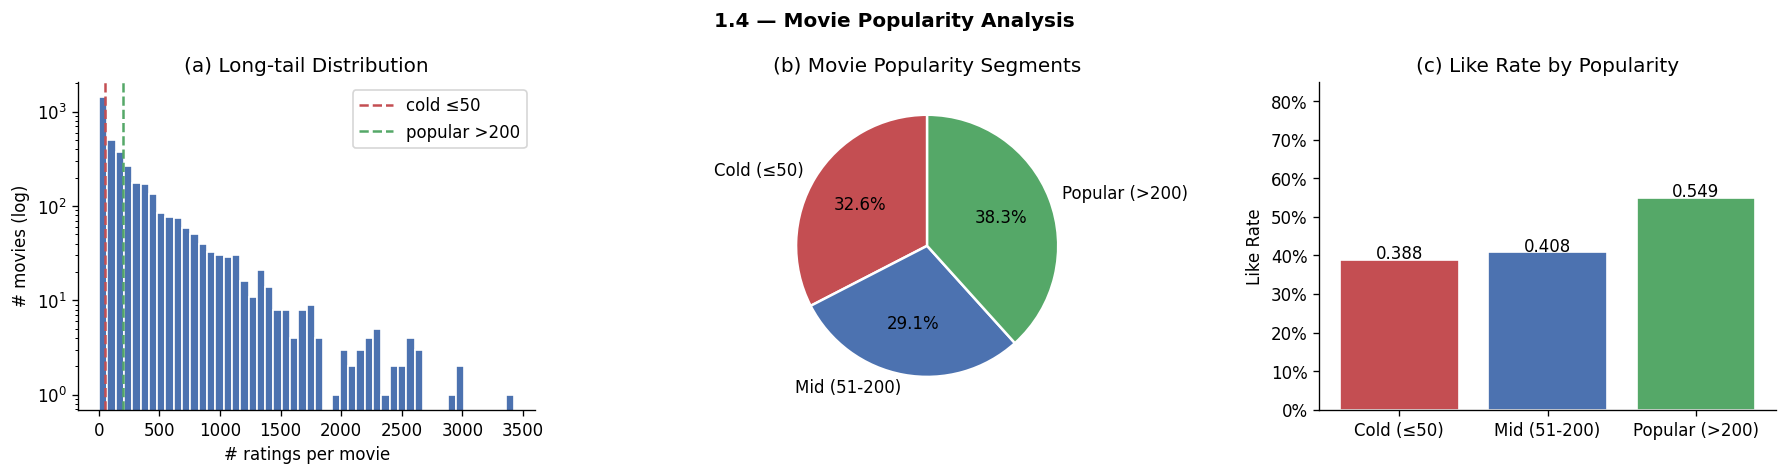


✓ popularity is added movies dataframe


In [ ]:
# ── Cell: 1.4 Popularity Analysis（additional EDA）──

# Use train data to calculate popularity (avoiding leaks).
movie_pop = (ratings.groupby('movie_id')
             .agg(n_ratings=('rating','count'),
                  like_rate=('like','mean'),
                  avg_rating=('rating','mean'))
             .reset_index())

# Three levels
movie_pop['popularity'] = pd.cut(
    movie_pop['n_ratings'],
    bins=[0, 50, 200, float('inf')],
    labels=['Cold (≤50)', 'Mid (51-200)', 'Popular (>200)']
)

print('── Popularity Distribution ──────────────────────')
summary = (movie_pop.groupby('popularity')
           .agg(n_movies=('movie_id','count'),
                median_ratings=('n_ratings','median'),
                mean_like_rate=('like_rate','mean'))
           .reset_index())
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('1.4 — Movie Popularity Analysis',
             fontsize=12, fontweight='bold')

# (a) Rating distribution (long tail)
ax = axes[0]
ax.hist(movie_pop['n_ratings'], bins=50, log=True,
        color='#4C72B0', edgecolor='white')
ax.axvline(50,  color='#C44E52', ls='--', lw=1.5, label='cold ≤50')
ax.axvline(200, color='#55A868', ls='--', lw=1.5, label='popular >200')
ax.set_xlabel('# ratings per movie')
ax.set_ylabel('# movies (log)')
ax.set_title('(a) Long-tail Distribution')
ax.legend()

# (b) popularity pie
ax = axes[1]
ax.pie(summary['n_movies'],
       labels=summary['popularity'],
       colors=['#C44E52','#4C72B0','#55A868'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('(b) Movie Popularity Segments')

# (c) like rate by popularity
ax = axes[2]
bars = ax.bar(summary['popularity'], summary['mean_like_rate'],
              color=['#C44E52','#4C72B0','#55A868'],
              edgecolor='white')
for bar, v in zip(bars, summary['mean_like_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
            f'{v:.3f}', ha='center', fontsize=10)
ax.set_ylabel('Like Rate')
ax.set_title('(c) Like Rate by Popularity')
ax.set_ylim(0, 0.85)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

# save to movies_df for future use - probably Phase 5
movies = movies.merge(
    movie_pop[['movie_id','n_ratings','popularity']],
    on='movie_id', how='left'
)
print('\n✓ popularity is added movies dataframe')

---
## Phase 2 — XGBoost User Simulator
### 2.0 Feature Engineering
All features built from **training data only** (no leakage).

| Feature group | Detail |
|---|---|
| SVD embeddings | TruncatedSVD on train rating matrix → user/item k-dim vectors |
| User history pooling | Mean / recency-weighted mean of past item genres |
| Movie features | genre one-hot, year, popularity, avg rating |
| User features | gender, age, occupation |

In [31]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix

# ── SVD embeddings ────────────────────────────────────────────────────
def build_svd_features(train_df, n_components=32):
    """
    Fit TruncatedSVD on train rating matrix.
    Returns user_emb dict and item_emb dict.
    """
    user_idx = {u:i for i,u in enumerate(sorted(train_df['user_id'].unique()))}
    item_idx = {m:i for i,m in enumerate(sorted(train_df['movie_id'].unique()))}

    rows = train_df['user_id'].map(user_idx)
    cols = train_df['movie_id'].map(item_idx)
    vals = train_df['rating'].astype(float)
    mat  = csr_matrix((vals, (rows, cols)),
                      shape=(len(user_idx), len(item_idx)))

    svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_SEED)
    U   = svd.fit_transform(mat)          # (n_users, k)
    V   = svd.components_.T               # (n_items, k)

    U = normalize(U)
    V = normalize(V)

    user_emb = {u: U[i] for u,i in user_idx.items()}
    item_emb = {m: V[i] for m,i in item_idx.items()}
    zero_u   = np.zeros(n_components)
    zero_i   = np.zeros(n_components)
    return user_emb, item_emb, zero_u, zero_i

# ── User history pooling ──────────────────────────────────────────────
def build_user_history(train_df, movies_df, mode='mean'):
    genre_cols = [c for c in movies_df.columns if c.startswith('genre_')]
    movie_genres = movies_df.set_index('movie_id')[genre_cols].copy()

    # ★ Genre vector normalization for each film
    # e.g. 3 genres, each reduced to 1/3 instead of all being 1
    row_sums = movie_genres.sum(axis=1).replace(0, 1)
    movie_genres = movie_genres.div(row_sums, axis=0)

    merged = (train_df
              .merge(movie_genres.reset_index(), on='movie_id', how='left')
              .sort_values(['user_id', 'timestamp']))

    user_hist = {}
    for uid, grp in merged.groupby('user_id', sort=False):
        G = grp[genre_cols].values.astype(float)  # shape: (T, 18)

        if mode == 'recency':
            ts = grp['timestamp'].values
            days_ago = (ts.max() - ts) / 86400    # Most recent
            weights = np.exp(-days_ago / 180)      # Half-life decay: 180 days
            weights /= weights.sum()
            user_hist[uid] = (G * weights[:, None]).sum(axis=0)
        else:
            user_hist[uid] = G.mean(axis=0)

    zero = np.zeros(len(genre_cols))
    return user_hist, zero, genre_cols

# ── Movie-level statistics (from train only) ──────────────────────────
def build_movie_stats(train_df):
    stats = (train_df.groupby('movie_id')
             .agg(train_n_ratings=('rating','count'),
                  train_avg_rating=('rating','mean'),
                  train_like_rate=('like','mean'))
             .reset_index())
    return stats

# ── Assemble feature matrix ───────────────────────────────────────────
def build_feature_matrix(df, train_df, movies_df, users_df,
                         svd_k=32, pool_mode='mean'):
    """
    Build X (feature matrix) and y (labels) for any split.
    All statistics fitted on train_df only.
    """
    user_emb, item_emb, zero_u, zero_i = build_svd_features(train_df, svd_k)
    user_hist, zero_hist, genre_cols   = build_user_history(train_df, movies_df, pool_mode)
    movie_stats = build_movie_stats(train_df)
    genre_cols_m = [c for c in movies_df.columns if c.startswith('genre_')]

    # Merge movie features
    feat_df = df.merge(movies_df[['movie_id','year','n_genres']+genre_cols_m],
                       on='movie_id', how='left')
    feat_df = feat_df.merge(movie_stats, on='movie_id', how='left')
    feat_df = feat_df.merge(
        users_df[['user_id','gender_enc','age_enc','occupation']],
        on='user_id', how='left'
    )
    feat_df['train_n_ratings']  = feat_df['train_n_ratings'].fillna(0)
    # feat_df['train_avg_rating'] = feat_df['train_avg_rating'].fillna(3.5)
    # feat_df['train_like_rate']  = feat_df['train_like_rate'].fillna(0.5)
    feat_df['year']             = feat_df['year'].fillna(1995)

    # The target movie genre is also normalized
    # (to be consistent with the user history).
    genre_cols_m = [c for c in movies_df.columns if c.startswith('genre_')]
    feat_df[genre_cols_m] = feat_df[genre_cols_m].div(
        feat_df[genre_cols_m].sum(axis=1).replace(0, 1), axis=0
    )

    # SVD embeddings
    U = np.vstack([user_emb.get(u, zero_u) for u in feat_df['user_id']])
    I = np.vstack([item_emb.get(m, zero_i) for m in feat_df['movie_id']])

    # User history pooling
    # H = np.vstack([user_hist.get(u, zero_hist) for u in feat_df['user_id']])

    # Static feature columns
    static_cols = (['year','n_genres',
                    'train_n_ratings',
                    'gender_enc','age_enc','occupation']
                   + genre_cols_m)
    S = feat_df[static_cols].values.astype(float)

    X = np.hstack([U, I, S])   # (n_samples, 2*k + n_genres + n_static)
    y = feat_df['like'].values

    col_names = (
        [f'user_svd_{i}' for i in range(svd_k)] +
        [f'item_svd_{i}' for i in range(svd_k)] +
        static_cols
    )
    return X, y, col_names

print('✓ Feature engineering functions defined')

✓ Feature engineering functions defined


In [30]:
# ── Cell: XGBoost Features Tables ──

print('── Features in build_feature_matrix ──────────────────')
print(f'Features Total: {len(col_names)}')
print()

# Print-out on cateegorization
user_svd  = [c for c in col_names if c.startswith('user_svd')]
item_svd  = [c for c in col_names if c.startswith('item_svd')]
static    = [c for c in col_names if not any(c.startswith(p)
             for p in ['user_svd','item_svd','hist_'])]

print(f'user_svd   : {len(user_svd)}   → {user_svd[:3]}...')
print(f'item_svd   : {len(item_svd)}   → {item_svd[:3]}...')
print(f'static     : {len(static)}   → {static}')

── Features in build_feature_matrix ──────────────────
Features Total: 89

user_svd   : 32   → ['user_svd_0', 'user_svd_1', 'user_svd_2']...
item_svd   : 32   → ['item_svd_0', 'item_svd_1', 'item_svd_2']...
static     : 25   → ['year', 'n_genres', 'train_n_ratings', 'train_avg_rating', 'gender_enc', 'age_enc', 'occupation', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Childrens', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Fantasy', 'genre_FilmNoir', 'genre_Horror', 'genre_Musical', 'genre_Mystery', 'genre_Romance', 'genre_SciFi', 'genre_Thriller', 'genre_War', 'genre_Western']


In [17]:
train, val, test = temporal_split_per_user(ratings)

[per-user split] train 797,758 | val 99,692 | test 102,759
✓ Number of leakage using per-user : 0
  train : 2000-04-25 → 2003-02-24 | n=797,758
  val   : 2000-04-25 → 2003-02-25 | n=99,692
  test  : 2000-04-25 → 2003-02-28 | n=102,759


### 2.1 Baseline
SVD 32-dim + n_ratings + demographics

In [32]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, log_loss, f1_score

# train, val, test = temporal_split_global(ratings)
train, val, test = temporal_split_per_user(ratings)

def evaluate(model, X, y, label=''):
    prob = model.predict_proba(X)[:,1]
    pred = (prob >= 0.5).astype(int)
    auc  = roc_auc_score(y, prob)
    ll   = log_loss(y, prob)
    f1   = f1_score(y, pred)
    print(f'  [{label}] AUC={auc:.4f}  LogLoss={ll:.4f}  F1={f1:.4f}')
    return dict(auc=auc, logloss=ll, f1=f1)

print('Building baseline features (SVD-32, mean pooling)...')
X_tr, y_tr, col_names = build_feature_matrix(train, train, movies, users, svd_k=32, pool_mode='mean')
X_va, y_va, _         = build_feature_matrix(val,   train, movies, users, svd_k=32, pool_mode='mean')
X_te, y_te, _         = build_feature_matrix(test,  train, movies, users, svd_k=32, pool_mode='mean')
print(f'Feature dim: {X_tr.shape[1]}')

baseline_params = dict(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_SEED, n_jobs=-1
)
model_baseline = xgb.XGBClassifier(**baseline_params)
model_baseline.fit(X_tr, y_tr,
                   eval_set=[(X_va, y_va)],
                   verbose=False)

print('\n── Baseline Results ─────────────────────────')
res_baseline = {}
res_baseline['train'] = evaluate(model_baseline, X_tr, y_tr, 'train')
res_baseline['val']   = evaluate(model_baseline, X_va, y_va, 'val  ')
res_baseline['test']  = evaluate(model_baseline, X_te, y_te, 'test ')

[per-user split] train 797,758 | val 99,692 | test 102,759
✓ Number of leakage using per-user : 0
  train : 2000-04-25 → 2003-02-24 | n=797,758
  val   : 2000-04-25 → 2003-02-25 | n=99,692
  test  : 2000-04-25 → 2003-02-28 | n=102,759
Building baseline features (SVD-32, mean pooling)...
Feature dim: 88

── Baseline Results ─────────────────────────
  [train] AUC=0.7878  LogLoss=0.5467  F1=0.7838
  [val  ] AUC=0.7779  LogLoss=0.5664  F1=0.7389
  [test ] AUC=0.7865  LogLoss=0.5604  F1=0.7343


         split  train    val   test   gap
 user_id split 0.7994 0.7211 0.7301 0.078
  global split 0.7972 0.7451 0.7514 0.052
per-user split 0.7878 0.7779 0.7865 0.013


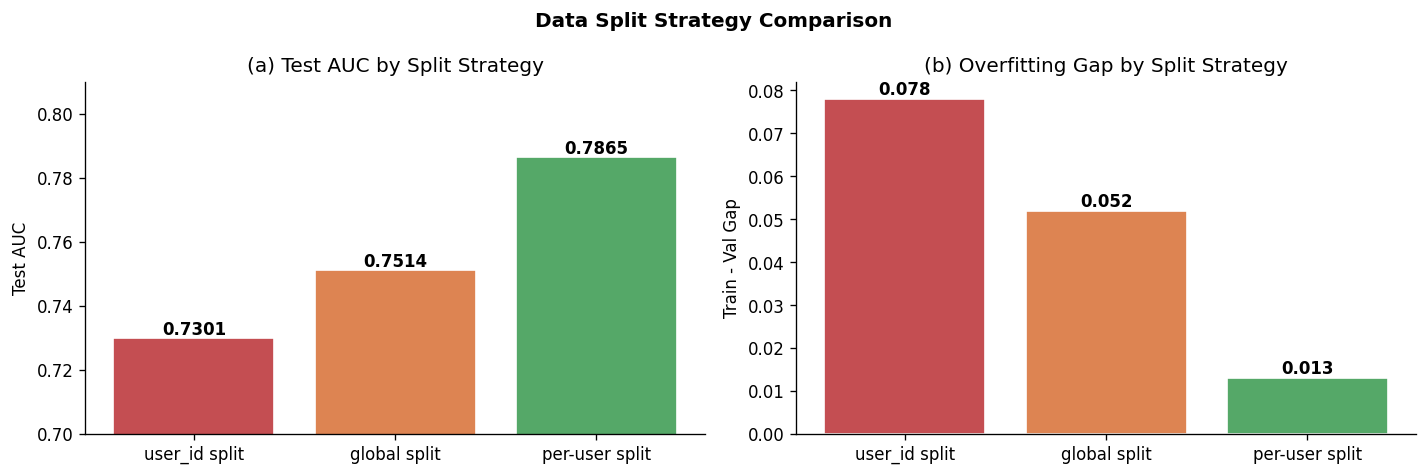

In [ ]:
# ── Cell: Comparison Summary for three types of splitting ──

results_split = pd.DataFrame([
    {'split': 'user_id split',  'train': 0.7994, 'val': 0.7211,
     'test': 0.7301, 'gap': 0.078},
    {'split': 'global split',   'train': 0.7972, 'val': 0.7451,
     'test': 0.7514, 'gap': 0.052},
    {'split': 'per-user split', 'train': 0.7878, 'val': 0.7779,
     'test': 0.7865, 'gap': 0.013},
])

print(results_split.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Data Split Strategy Comparison',
             fontsize=12, fontweight='bold')

# (a) Test AUC Compare
ax = axes[0]
bars = ax.bar(results_split['split'], results_split['test'],
              color=['#C44E52','#DD8452','#55A868'], edgecolor='white')
for bar, v in zip(bars, results_split['test']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.001,
            f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Test AUC')
ax.set_title('(a) Test AUC by Split Strategy')
ax.set_ylim(0.70, 0.81)

# (b) Train-Val Gap Compare
ax = axes[1]
bars = ax.bar(results_split['split'], results_split['gap'],
              color=['#C44E52','#DD8452','#55A868'], edgecolor='white')
for bar, v in zip(bars, results_split['gap']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.001,
            f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Train - Val Gap')
ax.set_title('(b) Overfitting Gap by Split Strategy')

plt.tight_layout()
plt.show()

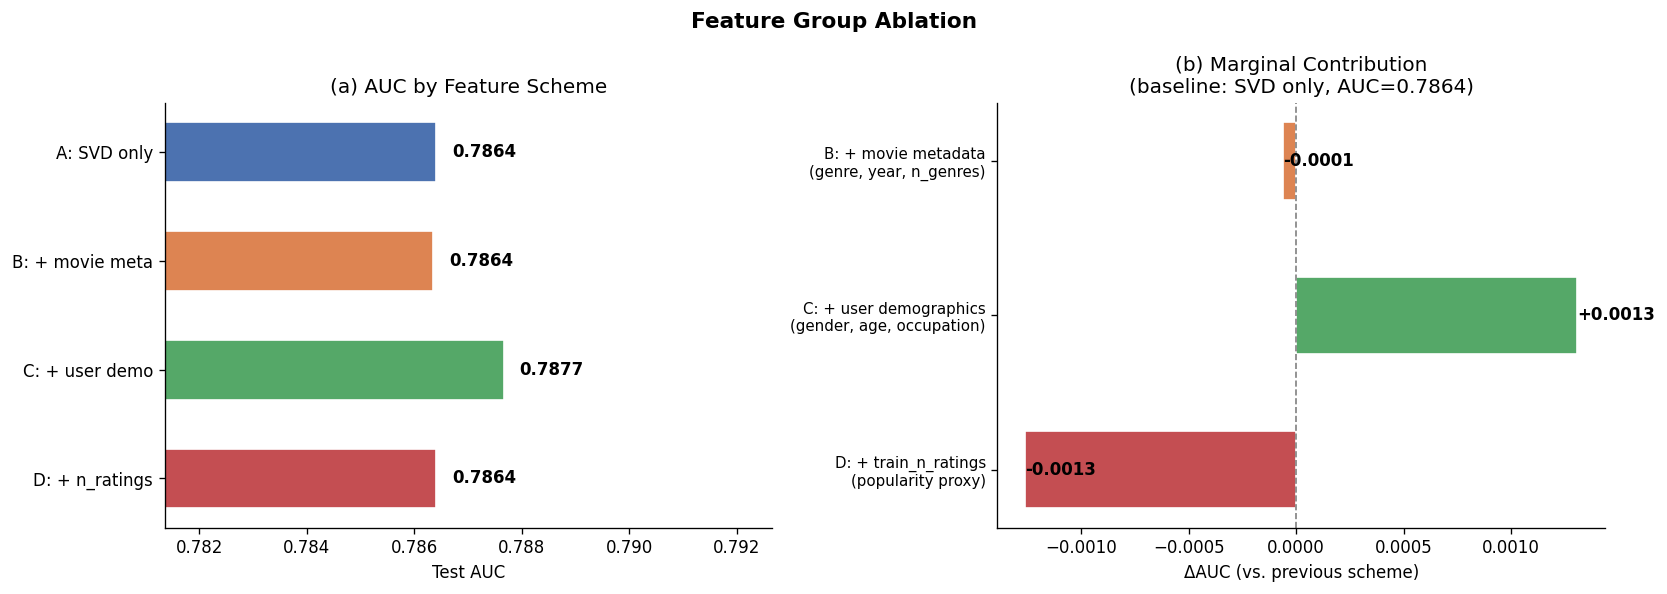

In [28]:
# ── Visualization (new cell, only plot) ─────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Group Ablation', fontsize=13, fontweight='bold')

# (a) AUC by scheme
ax = axes[0]
labels = ['A: SVD only',
          'B: + movie meta',
          'C: + user demo',
          'D: + n_ratings']
aucs = [auc_a, auc_b, auc_c, auc_d]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax.barh(range(len(labels)), aucs, color=colors, edgecolor='white', height=0.55)
for i, (bar, v) in enumerate(zip(bars, aucs)):
    ax.text(v + 0.0003, i, f'{v:.4f}',
            va='center', fontsize=10, fontweight='bold')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Test AUC')
ax.set_title('(a) AUC by Feature Scheme')
ax.set_xlim(min(aucs) - 0.005, max(aucs) + 0.005)
ax.invert_yaxis()

# (b) Marginal ΔAUC
ax = axes[1]
delta_labels = ['B: + movie metadata\n(genre, year, n_genres)',
                'C: + user demographics\n(gender, age, occupation)',
                'D: + train_n_ratings\n(popularity proxy)']
delta_vals = [auc_b - auc_a, auc_c - auc_b, auc_d - auc_c]
delta_colors = ['#DD8452', '#55A868', '#C44E52']
bars = ax.barh(range(len(delta_labels)), delta_vals,
               color=delta_colors, edgecolor='white', height=0.5)
for i, (bar, v) in enumerate(zip(bars, delta_vals)):
    # Place label on the right side of positive bars, left side of negative
    if v >= 0:
        ax.text(v, i, f'{v:+.4f}', va='center', fontsize=10, fontweight='bold')
    else:
        ax.text(v, i, f'{v:+.4f}', va='center', ha='left', fontsize=10, fontweight='bold')
ax.axvline(0, color='gray', lw=1, ls='--')
ax.set_yticks(range(len(delta_labels)))
ax.set_yticklabels(delta_labels, fontsize=9)
ax.set_xlabel('ΔAUC (vs. previous scheme)')
ax.set_title(f'(b) Marginal Contribution\n(baseline: SVD only, AUC={auc_a:.4f})')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 2.2 Feature Engineering Ablation
SVD dimension = 8 / 16 / 32 / 64 / 128


── : SVD dimension ─────────────────────────────────
  SVD k=8                             AUC=0.7755  LogLoss=0.5701
    Runtime: 43.3s
  SVD k=16                            AUC=0.7816  LogLoss=0.5646
    Runtime: 61.3s
  SVD k=32                            AUC=0.7865  LogLoss=0.5604
    Runtime: 69.5s
  SVD k=64                            AUC=0.7898  LogLoss=0.5573
    Runtime: 111.1s
  SVD k=128                           AUC=0.7922  LogLoss=0.5551
    Runtime: 213.4s
  SVD k=256                           AUC=0.7943  LogLoss=0.5530
    Runtime: 462.9s


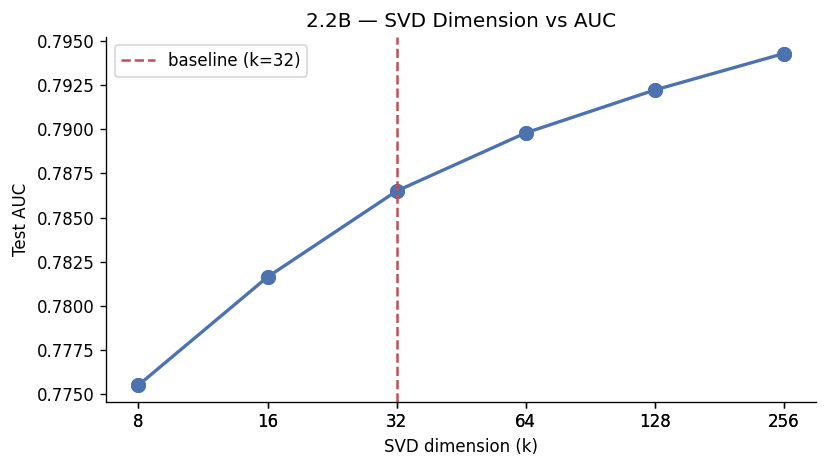

In [9]:
ablation_results = []

def run_ablation(name, svd_k=32, pool_mode='mean', params=None):
    if params is None:
        params = baseline_params
    X_tr_, y_tr_, _ = build_feature_matrix(train, train, movies, users, svd_k, pool_mode)
    X_va_, y_va_, _ = build_feature_matrix(val,   train, movies, users, svd_k, pool_mode)
    X_te_, y_te_, _ = build_feature_matrix(test,  train, movies, users, svd_k, pool_mode)
    m = xgb.XGBClassifier(**{**params, 'use_label_encoder':False,
                              'eval_metric':'logloss','random_state':RANDOM_SEED,'n_jobs':-1})
    m.fit(X_tr_, y_tr_, eval_set=[(X_va_, y_va_)], verbose=False)
    prob = m.predict_proba(X_te_)[:,1]
    auc  = roc_auc_score(y_te_, prob)
    ll   = log_loss(y_te_, prob)
    print(f'  {name:<35} AUC={auc:.4f}  LogLoss={ll:.4f}')
    ablation_results.append({'name':name,'auc':auc,'logloss':ll})
    return m, auc

print('\n── : SVD dimension ─────────────────────────────────')
import time
svd_results = []
for k in [8, 16, 32, 64, 128, 256]:
    t0 = time.time()
    _, auc = run_ablation(f'SVD k={k}', svd_k=k)
    elapsed = time.time() - t0
    svd_results.append((k, auc, elapsed))
    print(f'    Runtime: {elapsed:.1f}s')
    svd_results.append((k, auc))

# SVD dimension plot
ks, aucs = zip(*svd_results)
plt.figure(figsize=(7,4))
plt.plot(ks, aucs, '-o', color=PALETTE[0], lw=2, markersize=8)
plt.axvline(32, color=PALETTE[3], ls='--', lw=1.5, label='baseline (k=32)')
plt.xlabel('SVD dimension (k)'); plt.ylabel('Test AUC')
plt.title('2.2B — SVD Dimension vs AUC'); plt.legend()
plt.xscale('log', base=2); plt.xticks(ks, ks)
plt.tight_layout(); plt.show()

### 2.3 Model Parameter Ablation
D: max_depth = 3 / 6 / 9 / 12  
E: L1 / L2 regularization  
F: n_estimators = 50 / 100 / 200 / 500

── D: max_depth ─────────────────────────────────────
  depth=2  train=0.7281  val=0.7303  test=0.7447  gap=-0.0022
  depth=3  train=0.7416  val=0.7418  test=0.7553  gap=-0.0002
  depth=4  train=0.7562  val=0.7539  test=0.7661  gap=0.0023
  depth=5  train=0.7718  val=0.7672  test=0.7772  gap=0.0046
  depth=6  train=0.7878  val=0.7779  test=0.7865  gap=0.0099
  depth=9  train=0.8471  val=0.8035  test=0.8069  gap=0.0436
  depth=12  train=0.9366  val=0.8128  test=0.8144  gap=0.1238

── E: Regularization ────────────────────────────────
  L1=0 L2=1                           AUC=0.7865  LogLoss=0.5604
  L1=0.1 L2=1                         AUC=0.7865  LogLoss=0.5602
  L1=1 L2=1                           AUC=0.7868  LogLoss=0.5598
  L1=0 L2=5                           AUC=0.7863  LogLoss=0.5605
  L1=0 L2=10                          AUC=0.7869  LogLoss=0.5599

── F: n_estimators ──────────────────────────────────
  n_estimators=50                     AUC=0.7565  LogLoss=0.5935
  n_estimators=1

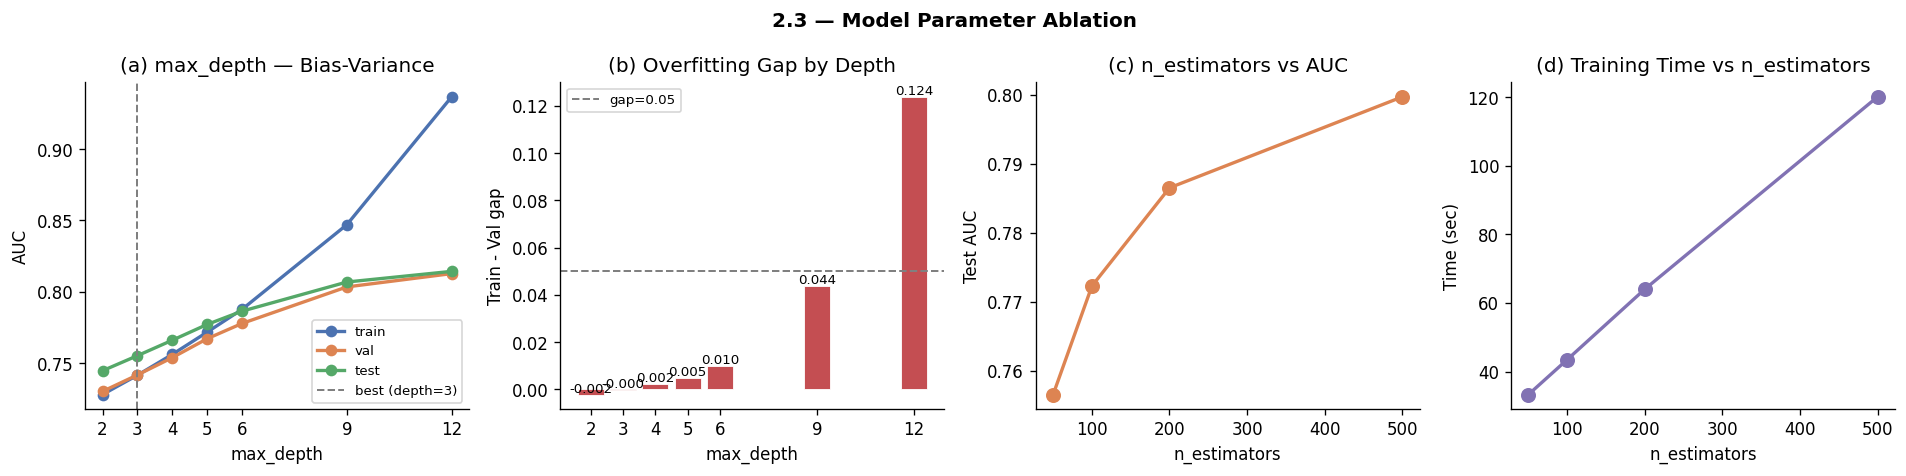

In [11]:
# ── Cell: 2.3 Model Parameter Ablation ──

# Use baseline features (SVD-32, mean pooling) for all param ablations
print('── D: max_depth ─────────────────────────────────────')
import time
depth_results = []
for d in [2, 3, 4, 5, 6, 9, 12]:
    p = {**baseline_params, 'max_depth': d}
    m = xgb.XGBClassifier(**p)
    t0 = time.time()
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    elapsed = time.time() - t0
    auc_tr = roc_auc_score(y_tr, m.predict_proba(X_tr)[:,1])
    auc_va = roc_auc_score(y_va, m.predict_proba(X_va)[:,1])
    auc_te = roc_auc_score(y_te, m.predict_proba(X_te)[:,1])
    gap    = auc_tr - auc_va
    print(f'  depth={d}  train={auc_tr:.4f}  val={auc_va:.4f}  '
          f'test={auc_te:.4f}  gap={gap:.4f}')
    depth_results.append({'depth':d, 'train':auc_tr,
                          'val':auc_va, 'test':auc_te,
                          'gap':gap, 'time':elapsed})

df_depth = pd.DataFrame(depth_results)

print('\n── E: Regularization ────────────────────────────────')
for alpha, lam in [(0,1),(0.1,1),(1,1),(0,5),(0,10)]:
    p = {**baseline_params, 'reg_alpha':alpha, 'reg_lambda':lam}
    run_ablation(f'L1={alpha} L2={lam}', params=p)

print('\n── F: n_estimators ──────────────────────────────────')
nest_results = []
for n in [50, 100, 200, 500]:
    p = {**baseline_params, 'n_estimators': n}
    t0 = time.time()
    _, auc = run_ablation(f'n_estimators={n}', params=p)
    elapsed = time.time() - t0
    nest_results.append((n, auc, elapsed))

# ── Plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('2.3 — Model Parameter Ablation', fontsize=12, fontweight='bold')

# (a) Train/Val/Test 三条线
ax = axes[0]
ax.plot(df_depth['depth'], df_depth['train'], '-o', label='train',
        color='#4C72B0', lw=2)
ax.plot(df_depth['depth'], df_depth['val'],   '-o', label='val',
        color='#DD8452', lw=2)
ax.plot(df_depth['depth'], df_depth['test'],  '-o', label='test',
        color='#55A868', lw=2)
ax.axvline(3, color='gray', ls='--', lw=1.2, label='best (depth=3)')
ax.set_xlabel('max_depth'); ax.set_ylabel('AUC')
ax.set_title('(a) max_depth — Bias-Variance')
ax.set_xticks(df_depth['depth']); ax.legend(fontsize=8)

# (b) Overfitting Gap
ax = axes[1]
ax.bar(df_depth['depth'], df_depth['gap'],
       color='#C44E52', edgecolor='white', linewidth=0.5)
for _, row in df_depth.iterrows():
    ax.text(row['depth'], row['gap'] + 0.001,
            f"{row['gap']:.3f}", ha='center', fontsize=8)
ax.axhline(0.05, color='gray', ls='--', lw=1.2, label='gap=0.05')
ax.set_xlabel('max_depth'); ax.set_ylabel('Train - Val gap')
ax.set_title('(b) Overfitting Gap by Depth')
ax.set_xticks(df_depth['depth']); ax.legend(fontsize=8)

# (c) n_estimators
ns, na, nt = zip(*nest_results)

ax = axes[2]
ax.plot(ns, na, '-o', color='#DD8452', lw=2, markersize=8)
ax.set_xlabel('n_estimators'); ax.set_ylabel('Test AUC')
ax.set_title('(c) n_estimators vs AUC')

# (d) n_estimators vs training time
ax = axes[3]
ax.plot(ns, nt, '-o', color='#8172B3', lw=2, markersize=8)
ax.set_xlabel('n_estimators'); ax.set_ylabel('Time (sec)')
ax.set_title('(d) Training Time vs n_estimators')

plt.tight_layout(); plt.show()

 ## ── Cell: Final Model with Optimal Parameters ──

In [12]:
best_params = dict(
    n_estimators    = 500,
    max_depth       = 6,
    learning_rate   = 0.05,
    reg_alpha       = 0,      # L1
    reg_lambda      = 1,      # L2
    subsample       = 0.8,
    colsample_bytree= 0.8,
    random_state    = RANDOM_SEED,
    n_jobs          = -1
)


# ── Cell: Best Model Final Results ──

model_best = xgb.XGBClassifier(**best_params)
model_best.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

print('── Best Model Results ───────────────────────────────')
auc_tr_best = None
for name, X, y in [('train', X_tr, y_tr),
                    ('val',   X_va, y_va),
                    ('test',  X_te, y_te)]:
    prob = model_best.predict_proba(X)[:, 1]
    auc  = roc_auc_score(y, prob)
    ll   = log_loss(y, prob)
    f1   = f1_score(y, (prob >= 0.5).astype(int))
    if name == 'train':
        auc_tr_best = auc
    gap = f'  gap={auc_tr_best - auc:.4f}' if name == 'val' else ''
    print(f'  [{name:<5}] AUC={auc:.4f}  LogLoss={ll:.4f}  F1={f1:.4f}{gap}')

── Best Model Results ───────────────────────────────
  [train] AUC=0.8155  LogLoss=0.5184  F1=0.7978
  [val  ] AUC=0.7953  LogLoss=0.5477  F1=0.7462  gap=0.0202
  [test ] AUC=0.7997  LogLoss=0.5447  F1=0.7391


In [17]:
# ── Cell: TimeSeriesSplit CV（for Stability Veri）──

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print('── Time Series CV (5 folds) ─────────────────────────')
print(f'  Total train samples: {len(X_tr):,}')
print()

cv_aucs = []
cv_lls  = []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_tr), 1):
    X_f_tr, X_f_va = X_tr[tr_idx], X_tr[va_idx]
    y_f_tr, y_f_va = y_tr[tr_idx], y_tr[va_idx]

    m = xgb.XGBClassifier(**best_params)
    m.fit(X_f_tr, y_f_tr,
          eval_set=[(X_f_va, y_f_va)],
          verbose=False)

    prob = m.predict_proba(X_f_va)[:, 1]
    auc  = roc_auc_score(y_f_va, prob)
    ll   = log_loss(y_f_va, prob)
    cv_aucs.append(auc)
    cv_lls.append(ll)

    print(f'  Fold {fold}  train={len(tr_idx):,}  val={len(va_idx):,}  '
          f'AUC={auc:.4f}  LogLoss={ll:.4f}')

print()
print(f'  CV AUC  : {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}')
print(f'  CV LL   : {np.mean(cv_lls):.4f} ± {np.std(cv_lls):.4f}')
print(f'  Test AUC: 0.7300  ← single split result')
print()
print(f'  Conclusion: Difference CV Avg. and Test AUC = '
      f'{abs(np.mean(cv_aucs) - 0.7300):.4f}')

── Time Series CV (5 folds) ─────────────────────────
  Total train samples: 797,758

  Fold 1  train=132,963  val=132,959  AUC=0.7456  LogLoss=0.5864
  Fold 2  train=265,922  val=132,959  AUC=0.7409  LogLoss=0.5825
  Fold 3  train=398,881  val=132,959  AUC=0.7520  LogLoss=0.5788
  Fold 4  train=531,840  val=132,959  AUC=0.7428  LogLoss=0.5819
  Fold 5  train=664,799  val=132,959  AUC=0.7431  LogLoss=0.5774

  CV AUC  : 0.7449 ± 0.0039
  CV LL   : 0.5814 ± 0.0031
  Test AUC: 0.7300  ← single split result

  Conclusion: Difference CV Avg. and Test AUC = 0.0149


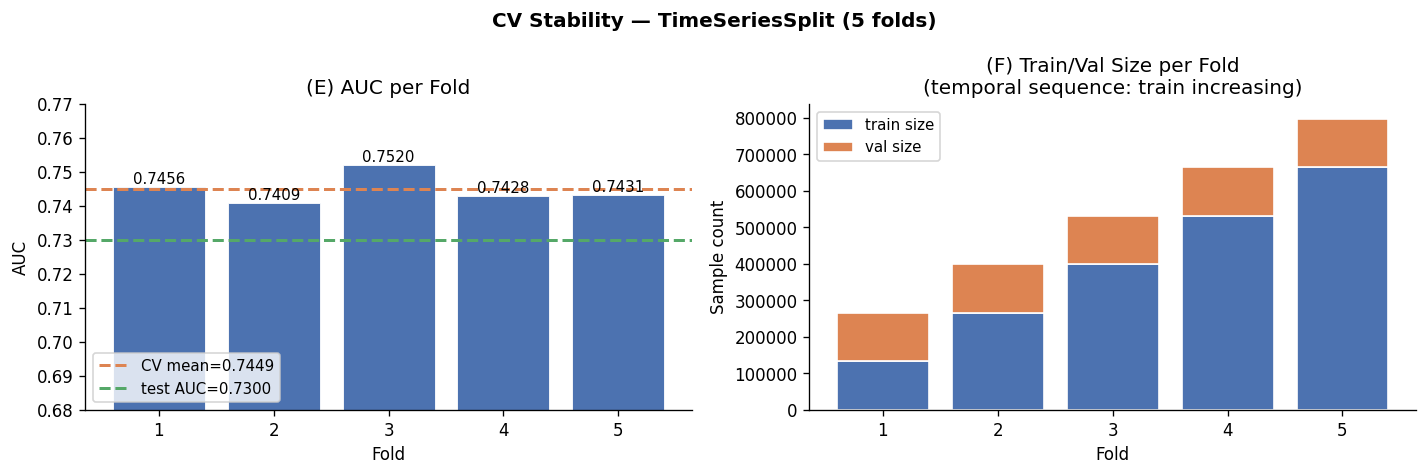

In [42]:
# ── Plot：fold AUC Stability ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CV Stability — TimeSeriesSplit (5 folds)',
             fontsize=12, fontweight='bold')

# (E) AUC per fold
ax = axes[0]
ax.bar(range(1, 6), cv_aucs, color='#4C72B0',
       edgecolor='white', linewidth=0.5)
ax.axhline(np.mean(cv_aucs), color='#DD8452', ls='--',
           lw=1.8, label=f'CV mean={np.mean(cv_aucs):.4f}')
ax.axhline(0.7300, color='#55A868', ls='--',
           lw=1.8, label='test AUC=0.7300')
for i, v in enumerate(cv_aucs):
    ax.text(i+1, v+0.001, f'{v:.4f}', ha='center', fontsize=9)
ax.set_xlabel('Fold'); ax.set_ylabel('AUC')
ax.set_title('(E) AUC per Fold')
ax.set_ylim(0.68, 0.77)
ax.legend(fontsize=9, loc='lower left')

# (F) fold size increase（Time series characteristics visualization）
ax = axes[1]
train_sizes = [len(tr) for tr, va in tscv.split(X_tr)]
val_sizes   = [len(va) for tr, va in tscv.split(X_tr)]
x = range(1, 6)
ax.bar(x, train_sizes, label='train size',
       color='#4C72B0', edgecolor='white')
ax.bar(x, val_sizes, bottom=train_sizes,
       label='val size', color='#DD8452', edgecolor='white')
ax.set_xlabel('Fold'); ax.set_ylabel('Sample count')
ax.set_title('(F) Train/Val Size per Fold\n(temporal sequence: train increasing)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
# Examine the distribution of like_rate in the 'val set' in each fold.
tscv = TimeSeriesSplit(n_splits=5)
for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_tr), 1):
    like_rate = y_tr[va_idx].mean()
    n_users   = len(np.unique(
        train.iloc[va_idx]['user_id'].values))
    print(f'Fold {fold}: like_rate={like_rate:.3f}  '
          f'n_users={n_users:,}')

Fold 1: like_rate=0.573  n_users=909
Fold 2: like_rate=0.599  n_users=1,105
Fold 3: like_rate=0.576  n_users=943
Fold 4: like_rate=0.593  n_users=998
Fold 5: like_rate=0.602  n_users=1,030


### 2.4 Diagnostics
G: Feature Importance  |  H: SHAP  |  I: Calibration Curve  |  J: Cold-start vs Active

── J: AUC by User Segment ───────────────────────────
  Cold (≤50)           n= 6,719  AUC=0.7476  LogLoss=0.5627
  Regular (51–199)     n=29,628  AUC=0.7695  LogLoss=0.5629
  Active (≥200)        n=66,412  AUC=0.8093  LogLoss=0.5348


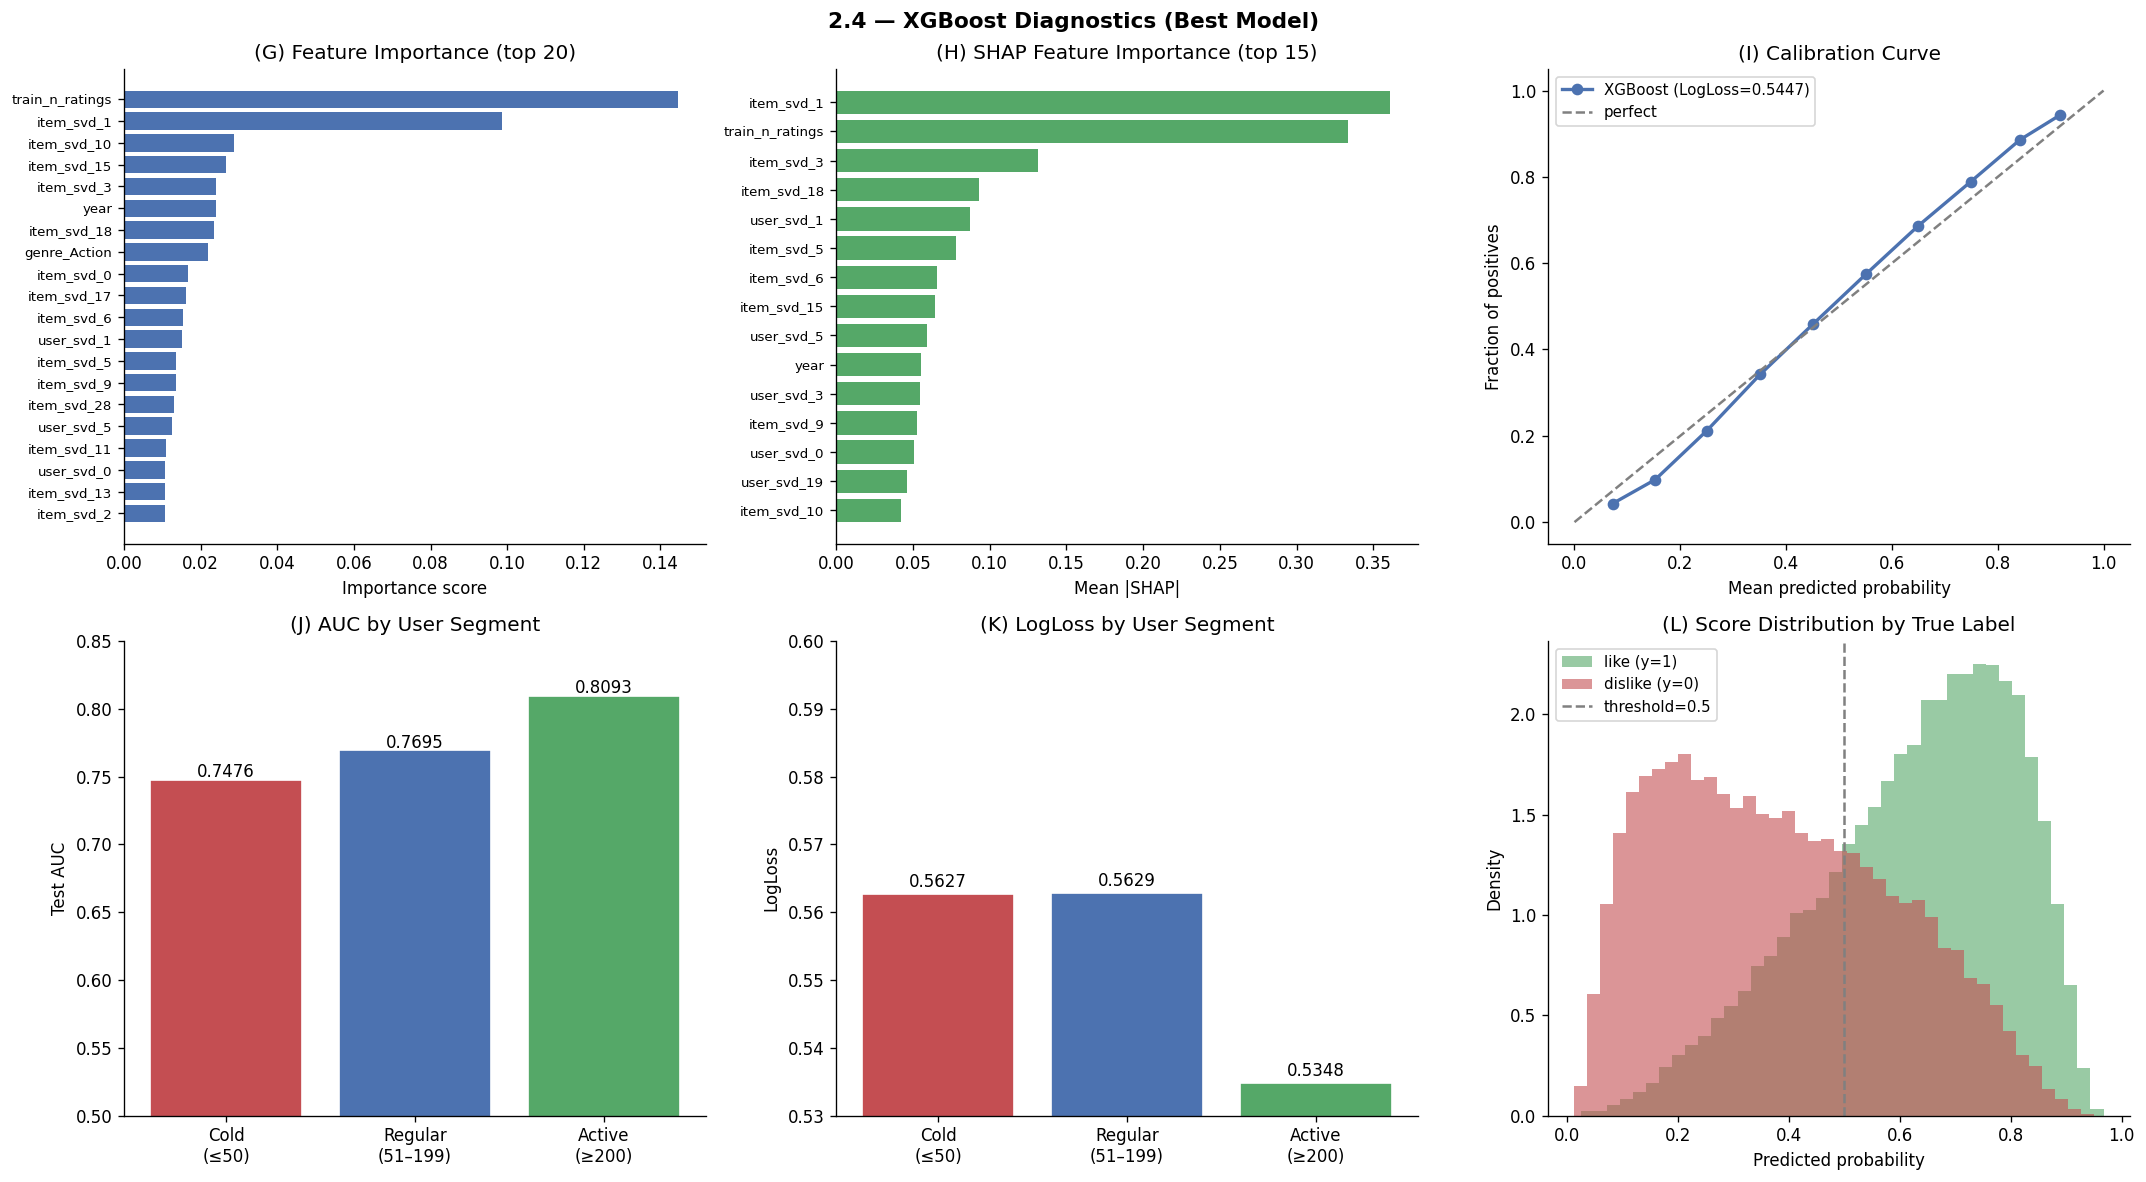


── Overall Test Metrics ─────────────────────────────
  AUC      = 0.7997
  LogLoss  = 0.5447
  F1       = 0.7391


In [39]:
# ── Cell: 2.4 Diagnostics. ──

import shap
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('2.4 — XGBoost Diagnostics (Best Model)', fontsize=13, fontweight='bold')

prob_te = model_best.predict_proba(X_te)[:, 1]
ll_te   = log_loss(y_te, prob_te)

# ── G: Feature Importance (top 20) ──────────────────────────
ax = axes[0, 0]
imp   = pd.Series(model_best.feature_importances_, index=col_names)
top20 = imp.nlargest(20)
ax.barh(range(20), top20.values[::-1], color='#4C72B0')
ax.set_yticks(range(20))
ax.set_yticklabels(top20.index[::-1], fontsize=8)
ax.set_xlabel('Importance score')
ax.set_title('(G) Feature Importance (top 20)')

# ── H: SHAP (sample 2000) ────────────────────────────────────
ax = axes[0, 1]
idx_sample = np.random.RandomState(42).choice(len(X_te), 2000, replace=False)
explainer  = shap.TreeExplainer(model_best)
shap_vals  = explainer.shap_values(X_te[idx_sample])
mean_abs   = np.abs(shap_vals).mean(axis=0)
top_shap   = pd.Series(mean_abs, index=col_names).nlargest(15)
ax.barh(range(15), top_shap.values[::-1], color='#55A868')
ax.set_yticks(range(15))
ax.set_yticklabels(top_shap.index[::-1], fontsize=8)
ax.set_xlabel('Mean |SHAP|')
ax.set_title('(H) SHAP Feature Importance (top 15)')

# ── I: Calibration Curve + LogLoss ───────────────────────────
ax = axes[0, 2]
frac_pos, mean_pred = calibration_curve(y_te, prob_te, n_bins=10)
ax.plot(mean_pred, frac_pos, '-o', color='#4C72B0', lw=2,
        label=f'XGBoost (LogLoss={ll_te:.4f})')
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1.5, label='perfect')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('(I) Calibration Curve')
ax.legend(fontsize=9)

# ── J: AUC by User Segment（Segmented by full score）─────────────────
ax = axes[1, 0]
# ★ Use all ratings to calculate the total number of ratings for each user
user_n_all   = ratings.groupby('user_id').size()
cold_users   = user_n_all[user_n_all <= 50].index    # higher threshold
active_users = user_n_all[user_n_all >= 200].index

mask_cold    = np.isin(test['user_id'].values, cold_users)
mask_active  = np.isin(test['user_id'].values, active_users)
mask_regular = ~mask_cold & ~mask_active

print('── J: AUC by User Segment ───────────────────────────')
seg_results = {}
for label, mask in [('Cold\n(≤50)',     mask_cold),
                     ('Regular\n(51–199)', mask_regular),
                     ('Active\n(≥200)',  mask_active)]:
    if mask.sum() > 0:
        auc = roc_auc_score(y_te[mask], prob_te[mask])
        ll  = log_loss(y_te[mask], prob_te[mask])
        seg_results[label] = {'auc': auc, 'logloss': ll}
        print(f'  {label.replace(chr(10)," "):<20} '
              f'n={mask.sum():>6,}  AUC={auc:.4f}  LogLoss={ll:.4f}')

colors = ['#C44E52', '#4C72B0', '#55A868']
bars = ax.bar(seg_results.keys(),
              [v['auc'] for v in seg_results.values()],
              color=colors[:len(seg_results)], edgecolor='white')
for bar, v in zip(bars, seg_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v['auc'] + 0.002,
            f"{v['auc']:.4f}", ha='center', fontsize=10)
ax.set_ylabel('Test AUC'); ax.set_title('(J) AUC by User Segment')
ax.set_ylim(0.5, 0.85)

# ── K: LogLoss by User Segment ───────────────────────────────
ax = axes[1, 1]
bars = ax.bar(seg_results.keys(),
              [v['logloss'] for v in seg_results.values()],
              color=colors[:len(seg_results)], edgecolor='white')
for bar, v in zip(bars, seg_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v['logloss'] + 0.001,
            f"{v['logloss']:.4f}", ha='center', fontsize=10)
ax.set_ylabel('LogLoss'); ax.set_title('(K) LogLoss by User Segment')
ax.set_ylim(0.53, 0.60)

# ── L: Predicted probability distribution ────────────────────
ax = axes[1, 2]
ax.hist(prob_te[y_te==1], bins=40, alpha=0.6,
        color='#55A868', label='like (y=1)', density=True)
ax.hist(prob_te[y_te==0], bins=40, alpha=0.6,
        color='#C44E52', label='dislike (y=0)', density=True)
ax.axvline(0.5, color='gray', ls='--', lw=1.5, label='threshold=0.5')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Density')
ax.set_title('(L) Score Distribution by True Label')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'\n── Overall Test Metrics ─────────────────────────────')
print(f'  AUC      = {roc_auc_score(y_te, prob_te):.4f}')
print(f'  LogLoss  = {ll_te:.4f}')
print(f'  F1       = {f1_score(y_te, (prob_te>=0.5).astype(int)):.4f}')

In [35]:
# ── Cell: Ablation — Feature Group Contribution ──────────────────────
# Goal: Measure marginal contribution of each feature group
#   A: SVD only (64 dims)
#   B: A + movie metadata — genre one-hot, year, n_genres (84 dims)
#   C: B + user demographics — gender, age, occupation (87 dims)
#   D: C + train_n_ratings — popularity proxy (88 dims = your baseline)

import time
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, log_loss

genre_cols_m = [c for c in movies.columns if c.startswith('genre_')]

results_feature = []

def quick_xgb(X_tr, y_tr, X_va, y_va, X_te, y_te, name):
    t0 = time.time()
    m = xgb.XGBClassifier(**best_params)
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    prob = m.predict_proba(X_te)[:, 1]
    auc  = roc_auc_score(y_te, prob)
    ll   = log_loss(y_te, prob)
    elapsed = time.time() - t0
    print(f'  {name:<50} AUC={auc:.4f}  LL={ll:.4f}  ({elapsed:.1f}s)')
    results_feature.append({'name': name, 'auc': auc, 'logloss': ll})
    return auc

# ── Feature builders ─────────────────────────────────────────────────

def build_scheme_a(df, train_df, svd_k=32):
    """A: SVD only"""
    user_emb, item_emb, zero_u, zero_i = build_svd_features(train_df, svd_k)
    U = np.vstack([user_emb.get(u, zero_u) for u in df['user_id']])
    I = np.vstack([item_emb.get(m, zero_i) for m in df['movie_id']])
    return np.hstack([U, I]), df['like'].values

def build_scheme_b(df, train_df, movies_df, svd_k=32):
    """B: SVD + movie metadata (genre, year, n_genres)"""
    user_emb, item_emb, zero_u, zero_i = build_svd_features(train_df, svd_k)
    U = np.vstack([user_emb.get(u, zero_u) for u in df['user_id']])
    I = np.vstack([item_emb.get(m, zero_i) for m in df['movie_id']])

    feat_df = df[['movie_id']].merge(
        movies_df[['movie_id', 'year', 'n_genres'] + genre_cols_m],
        on='movie_id', how='left')
    feat_df['year'] = feat_df['year'].fillna(1995)
    feat_df[genre_cols_m] = feat_df[genre_cols_m].div(
        feat_df[genre_cols_m].sum(axis=1).replace(0, 1), axis=0)

    S = feat_df[['year', 'n_genres'] + genre_cols_m].values.astype(float)
    return np.hstack([U, I, S]), df['like'].values

def build_scheme_c(df, train_df, movies_df, users_df, svd_k=32):
    """C: SVD + movie metadata + user demographics"""
    user_emb, item_emb, zero_u, zero_i = build_svd_features(train_df, svd_k)
    U = np.vstack([user_emb.get(u, zero_u) for u in df['user_id']])
    I = np.vstack([item_emb.get(m, zero_i) for m in df['movie_id']])

    feat_df = df[['user_id', 'movie_id']].copy()
    feat_df = feat_df.merge(
        movies_df[['movie_id', 'year', 'n_genres'] + genre_cols_m],
        on='movie_id', how='left')
    feat_df = feat_df.merge(
        users_df[['user_id', 'gender_enc', 'age_enc', 'occupation']],
        on='user_id', how='left')
    feat_df['year'] = feat_df['year'].fillna(1995)
    feat_df[genre_cols_m] = feat_df[genre_cols_m].div(
        feat_df[genre_cols_m].sum(axis=1).replace(0, 1), axis=0)

    static_cols = (['year', 'n_genres',
                    'gender_enc', 'age_enc', 'occupation']
                   + genre_cols_m)
    S = feat_df[static_cols].values.astype(float)
    return np.hstack([U, I, S]), df['like'].values

def build_scheme_d(df, train_df, movies_df, users_df, svd_k=32):
    """D: C + train_n_ratings (= your full baseline, 88 dims)"""
    user_emb, item_emb, zero_u, zero_i = build_svd_features(train_df, svd_k)
    U = np.vstack([user_emb.get(u, zero_u) for u in df['user_id']])
    I = np.vstack([item_emb.get(m, zero_i) for m in df['movie_id']])

    feat_df = df[['user_id', 'movie_id']].copy()
    feat_df = feat_df.merge(
        movies_df[['movie_id', 'year', 'n_genres'] + genre_cols_m],
        on='movie_id', how='left')
    feat_df = feat_df.merge(
        users_df[['user_id', 'gender_enc', 'age_enc', 'occupation']],
        on='user_id', how='left')
    feat_df['year'] = feat_df['year'].fillna(1995)
    feat_df[genre_cols_m] = feat_df[genre_cols_m].div(
        feat_df[genre_cols_m].sum(axis=1).replace(0, 1), axis=0)

    # Popularity: train_n_ratings
    movie_counts = (train_df.groupby('movie_id')['rating']
                    .count().reset_index()
                    .rename(columns={'rating': 'train_n_ratings'}))
    feat_df = feat_df.merge(movie_counts, on='movie_id', how='left')
    feat_df['train_n_ratings'] = feat_df['train_n_ratings'].fillna(0)

    static_cols = (['year', 'n_genres', 'train_n_ratings',
                    'gender_enc', 'age_enc', 'occupation']
                   + genre_cols_m)
    S = feat_df[static_cols].values.astype(float)
    return np.hstack([U, I, S]), df['like'].values


# ── Run ablation ─────────────────────────────────────────────────────

print('═' * 60)
print('FEATURE GROUP ABLATION')
print('═' * 60)
print(f'  {"Scheme":<50} {"AUC":>7}  {"LL":>7}')
print(f'  {"─" * 58}')

X_tr_a, y_tr_a = build_scheme_a(train, train)
X_va_a, y_va_a = build_scheme_a(val,   train)
X_te_a, y_te_a = build_scheme_a(test,  train)
auc_a = quick_xgb(X_tr_a, y_tr_a, X_va_a, y_va_a, X_te_a, y_te_a,
                   'A: SVD only (64 dims)')

X_tr_b, y_tr_b = build_scheme_b(train, train, movies)
X_va_b, y_va_b = build_scheme_b(val,   train, movies)
X_te_b, y_te_b = build_scheme_b(test,  train, movies)
auc_b = quick_xgb(X_tr_b, y_tr_b, X_va_b, y_va_b, X_te_b, y_te_b,
                   'B: + movie metadata (84 dims)')

X_tr_c, y_tr_c = build_scheme_c(train, train, movies, users)
X_va_c, y_va_c = build_scheme_c(val,   train, movies, users)
X_te_c, y_te_c = build_scheme_c(test,  train, movies, users)
auc_c = quick_xgb(X_tr_c, y_tr_c, X_va_c, y_va_c, X_te_c, y_te_c,
                   'C: + user demographics (87 dims)')

X_tr_d, y_tr_d = build_scheme_d(train, train, movies, users)
X_va_d, y_va_d = build_scheme_d(val,   train, movies, users)
X_te_d, y_te_d = build_scheme_d(test,  train, movies, users)
auc_d = quick_xgb(X_tr_d, y_tr_d, X_va_d, y_va_d, X_te_d, y_te_d,
                   'D: + train_n_ratings (88 dims = baseline)')


# ── Summary ──────────────────────────────────────────────────────────

print(f'\n── Marginal Contribution ────────────────────────────')
print(f'  SVD baseline:                    AUC = {auc_a:.4f}')
print(f'  + movie metadata (genre/year):  ΔAUC = {auc_b - auc_a:+.4f}')
print(f'  + user demographics:            ΔAUC = {auc_c - auc_b:+.4f}')
print(f'  + popularity (n_ratings):       ΔAUC = {auc_d - auc_c:+.4f}')
print(f'  Total (A → D):                 ΔAUC = {auc_d - auc_a:+.4f}')


════════════════════════════════════════════════════════════
FEATURE GROUP ABLATION
════════════════════════════════════════════════════════════
  Scheme                                                 AUC       LL
  ──────────────────────────────────────────────────────────
  A: SVD only (64 dims)                              AUC=0.7995  LL=0.5449  (101.9s)
  B: + movie metadata (84 dims)                      AUC=0.7997  LL=0.5447  (117.5s)
  C: + user demographics (87 dims)                   AUC=0.8003  LL=0.5440  (110.0s)
  D: + train_n_ratings (88 dims = baseline)          AUC=0.7997  LL=0.5447  (111.2s)

── Marginal Contribution ────────────────────────────
  SVD baseline:                    AUC = 0.7995
  + movie metadata (genre/year):  ΔAUC = +0.0003
  + user demographics:            ΔAUC = +0.0006
  + popularity (n_ratings):       ΔAUC = -0.0006
  Total (A → D):                 ΔAUC = +0.0002


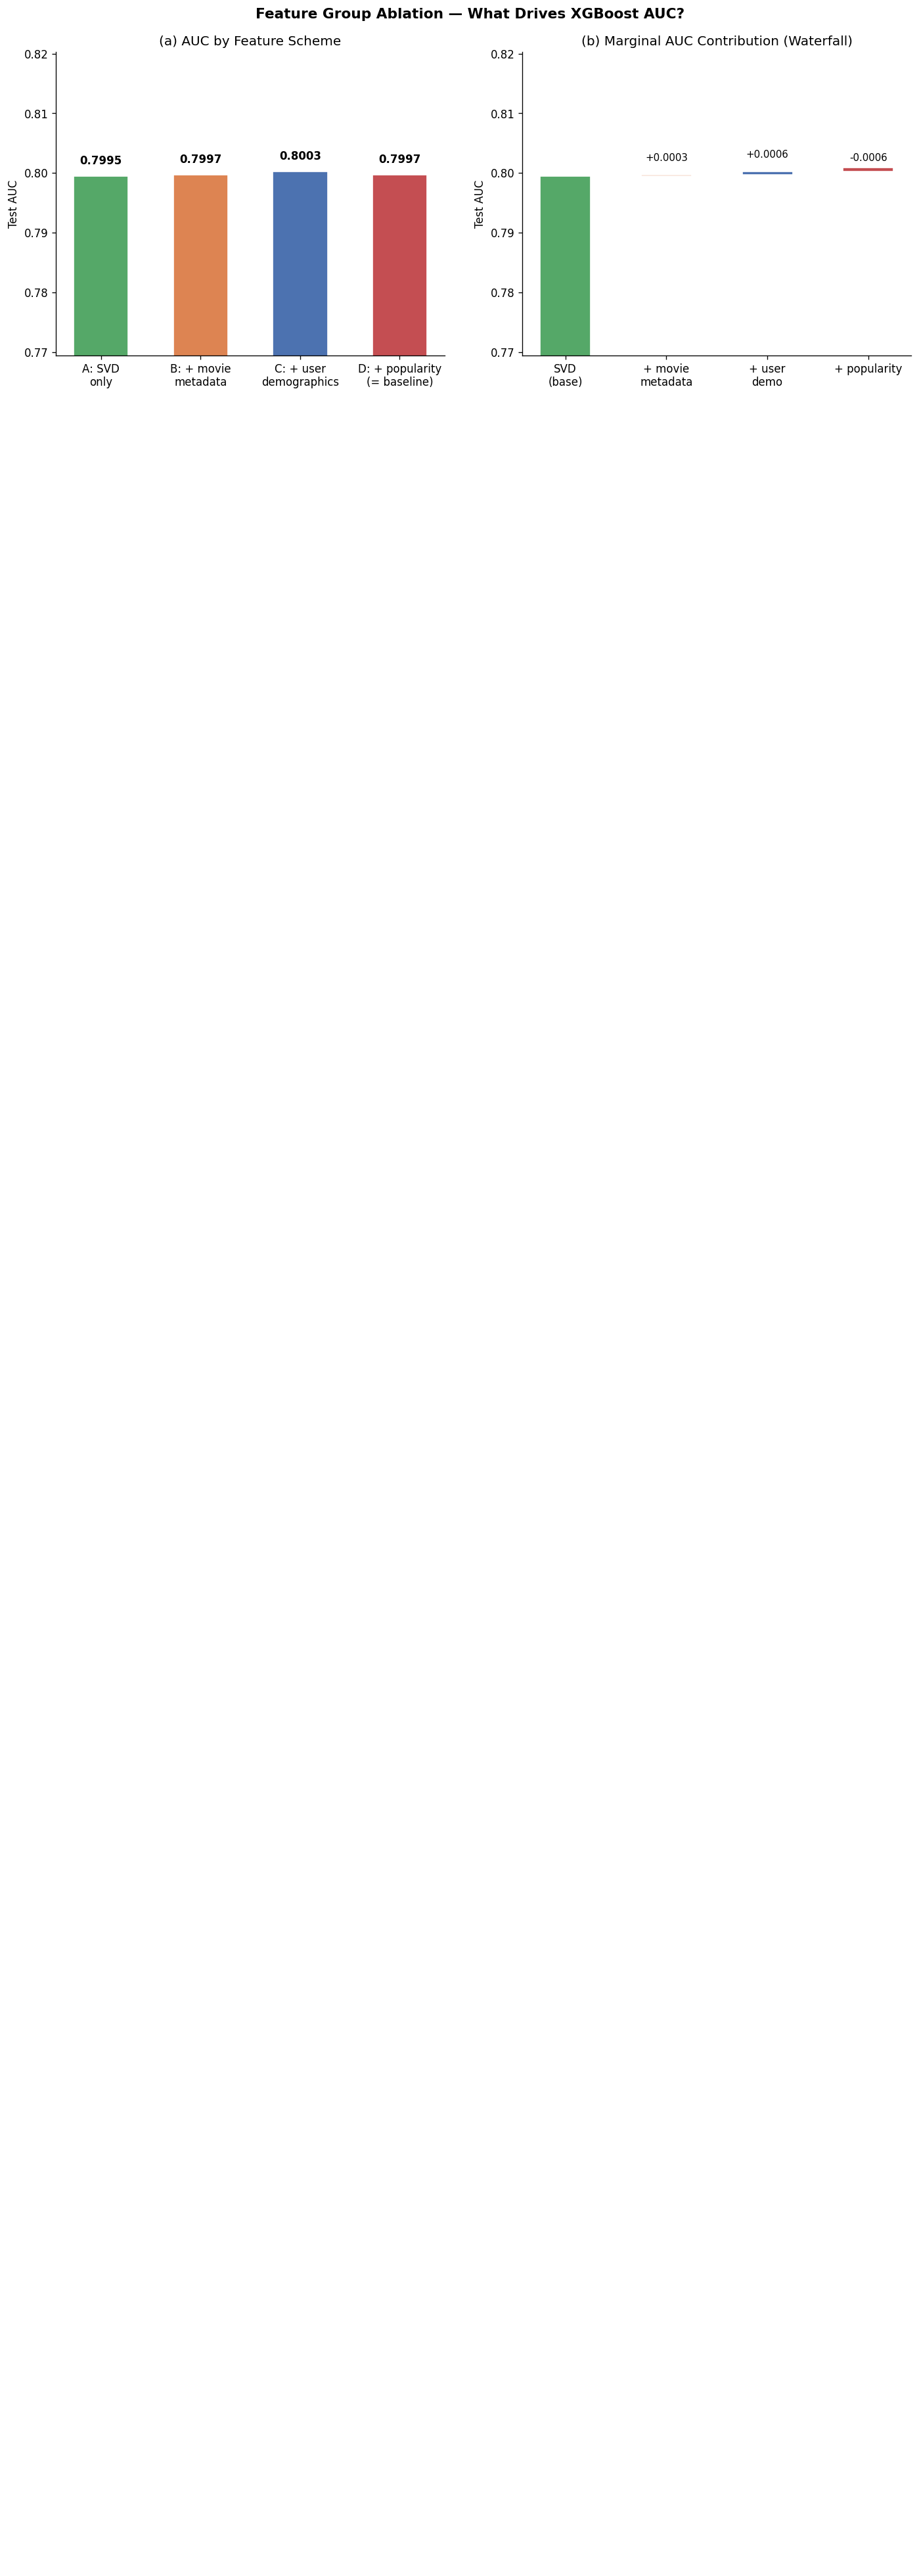


── Interpretation ──────────────────────────────────
  → User demographics provide the largest marginal gain.
  → Popularity contributes minimally — model relies on personalization.
    This is good for the RL agent: predictions reflect user preference,
    not just "recommend popular movies".

  SVD alone achieves 0.7995, covering 100.0% of the full model AUC.


In [38]:

# ── Plot ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.suptitle('Feature Group Ablation — What Drives XGBoost AUC?',
             fontsize=13, fontweight='bold')

# (a) AUC bar chart
ax = axes[0]
labels = ['A: SVD\nonly',
          'B: + movie\nmetadata',
          'C: + user\ndemographics',
          'D: + popularity\n(= baseline)']
aucs   = [auc_a, auc_b, auc_c, auc_d]
colors = ['#55A868', '#DD8452', '#4C72B0', '#C44E52']
bars   = ax.bar(labels, aucs, color=colors,
                edgecolor='white', width=0.55)
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2,
            v + 0.002, f'{v:.4f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Test AUC')
ax.set_title('(a) AUC by Feature Scheme')
y_min = min(aucs) - 0.03
y_max = max(aucs) + 0.02
ax.set_ylim(y_min, y_max)

# (b) Waterfall: marginal contribution
ax = axes[1]
components = ['SVD\n(base)',
              '+ movie\nmetadata',
              '+ user\ndemo',
              '+ popularity']
deltas  = [auc_a,
           auc_b - auc_a,
           auc_c - auc_b,
           auc_d - auc_c]
bottoms = [0, auc_a, auc_b, auc_c]
colors_w = ['#55A868', '#DD8452', '#4C72B0', '#C44E52']

for i, (comp, delta, bot, col) in enumerate(
        zip(components, deltas, bottoms, colors_w)):
    ax.bar(comp, abs(delta), bottom=bot, color=col,
           edgecolor='white', width=0.5)
    if abs(delta) > 0.003:
        ax.text(i, bot + delta/2, f'{delta:+.4f}',
                ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')
    else:
        ax.text(i, bot + delta + 0.002, f'{delta:+.4f}',
                ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Test AUC')
ax.set_title('(b) Marginal AUC Contribution (Waterfall)')
ax.set_ylim(y_min, y_max)

# plt.tight_layout()
plt.show()

# ── Interpretation ───────────────────────────────────────────────────
print('\n── Interpretation ──────────────────────────────────')
max_delta = max(auc_b - auc_a, auc_c - auc_b, auc_d - auc_c)
if auc_b - auc_a == max_delta:
    print('  → Movie metadata (genre, year) is the largest contributor beyond SVD.')
elif auc_c - auc_b == max_delta:
    print('  → User demographics provide the largest marginal gain.')
else:
    print('  → Popularity (train_n_ratings) provides the largest marginal gain.')

if abs(auc_d - auc_c) < 0.005:
    print('  → Popularity contributes minimally — model relies on personalization.')
    print('    This is good for the RL agent: predictions reflect user preference,')
    print('    not just "recommend popular movies".')
else:
    print(f'  → Popularity adds {auc_d - auc_c:+.4f} — notable contribution.')
    print('    The RL agent may learn to exploit this shortcut.')

print(f'\n  SVD alone achieves {auc_a:.4f}, covering '
      f'{(auc_a / auc_d * 100):.1f}% of the full model AUC.')

In [ ]:
# ── Cell: Verifying genre_Drama distribution ──

genre_cols = [c for c in movies.columns if c.startswith('genre_')]

# Drama ratio:
drama_rate = movies['genre_Drama'].mean()
print(f'Drama ratio: {drama_rate:.1%}')

# Drama movies' like rate vs non-Drama'a
merged = ratings.merge(movies[['movie_id','genre_Drama']], on='movie_id')
like_drama    = merged[merged['genre_Drama']==1]['like'].mean()
like_nondrama = merged[merged['genre_Drama']==0]['like'].mean()
print(f"Drama movies' like rate    : {like_drama:.3f}")
print(f"non Drama movies' like rate : {like_nondrama:.3f}")

# Frequency of Drama's occurrence in rating data
drama_in_ratings = merged['genre_Drama'].mean()
print(f'Drama ratio in rating data   : {drama_in_ratings:.1%}')

Drama ratio: 41.3%
Drama movies' like rate    : 0.644
non Drama movies' like rate : 0.537
Drama ratio in rating data   : 35.4%


### 2.5 Phase 2 Summary

In [40]:
print('='*55)
print('PHASE 2 SUMMARY — XGBoost')
print('='*55)
print(f"Baseline (SVD-32, mean pool) — test AUC : {res_baseline['test']['auc']:.4f}")
print(f"                            — test LL  : {res_baseline['test']['logloss']:.4f}")
print(f"                            — test F1  : {res_baseline['test']['f1']:.4f}")
print()
print('All ablation results:')
df_abl = pd.DataFrame(ablation_results).sort_values('auc', ascending=False)
print(df_abl.to_string(index=False))
print()
print('→ Next: Phase 3 GRU4Rec')

PHASE 2 SUMMARY — XGBoost
Baseline (SVD-32, mean pool) — test AUC : 0.7865
                            — test LL  : 0.5604
                            — test F1  : 0.7343

All ablation results:
            name      auc  logloss
n_estimators=500 0.799694 0.544708
n_estimators=500 0.799694 0.544708
       SVD k=256 0.794289 0.553026
       SVD k=128 0.792225 0.555089
        SVD k=64 0.789794 0.557307
      L1=0 L2=10 0.786918 0.559938
      L1=0 L2=10 0.786918 0.559938
       L1=1 L2=1 0.786815 0.559834
       L1=1 L2=1 0.786815 0.559834
     L1=0.1 L2=1 0.786546 0.560213
     L1=0.1 L2=1 0.786546 0.560213
        SVD k=32 0.786499 0.560361
n_estimators=200 0.786499 0.560361
       L1=0 L2=1 0.786499 0.560361
       L1=0 L2=1 0.786499 0.560361
n_estimators=200 0.786499 0.560361
       L1=0 L2=5 0.786251 0.560473
       L1=0 L2=5 0.786251 0.560473
        SVD k=16 0.781629 0.564583
         SVD k=8 0.775507 0.570130
n_estimators=100 0.772257 0.575754
n_estimators=100 0.772257 0.575754
 